<a href="https://colab.research.google.com/github/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/pathomics/microscopy_dicom_ann_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Working with DICOM Microscopy Bulk Simple Annotations in computational pathology


This tutorial is shared as part of the tutorials prepared by the Imaging Data Commons (IDC) team and available at https://github.com/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks.

If you are new to IDC and DICOM for digital pathology applications, you may want to check out other introductory tutorials on this topic available here: https://github.com/ImagingDataCommons/IDC-Tutorials/tree/master/notebooks/pathomics.

This tutorial is aimed at users of the IDC who are interested in understanding how to work with image-derived data for slide microscopy images. You will learn how to:
* select and download a specific type of image-derived data, namely delineations of cell nuclei represented as polygons
* parse the content stored in DICOM Microscopy Bulk Simple Annotations (MBSA/ANN) files
* utilize the cell nuclei contours for calculating quantitative features that may help in analyzing the annotated pathology slides

To learn more about the IDC, please visit the [IDC user guide](https://learn.canceridc.dev).

If you have any questions, bug reports, or feature requests, please feel free to contact us at the [IDC discussion forum](https://discourse.canceridc.dev)!

----------------------

Initial version: Jan 2025  
Updated: Aug 2026

## Background

There are different ways to store image-derived data in DICOM. The **cell nuclei delineations** in the [`Pan-Cancer-Nuclei-Seg-DICOM` collection](https://zenodo.org/records/14009675), which was recently added to the [NCI Imaging Data Commons (IDC)](https://portal.imaging.datacommons.cancer.gov/explore/filters/?analysis_results_id=Pan-Cancer-Nuclei-Seg-DICOM), are offered in two DICOM representations:
1. Polygons corresponding to the boundaries of the nuclei: DICOM **Microscopy Simple Bulk Annotations** (**MBSA**, often also abbreviated **ANN** after the corresponding DICOM `Modality` value)
2. Binary masks labeling the areas of the image corresponding to the individual nuclei: DICOM Segmentations (SEG)

In this notebook, we will concentrate on the first representation, discuss how the MBSA objects in the `Pan-Cancer-Nuclei-Seg-DICOM` collection are organized and how the cell nuclei contours can be used in analysis. The DICOM SEG representation will be covered separately and linked here upon finalization.

The delineations of cell nuclei in the `Pan-Cancer-Nuclei-Seg-DICOM` collection were **automatically derived** for over 5000 whole slide images (WSIs) across 14 different cancer types. The underlying WSIs originate from the following TCGA collections, all of which are also available in the IDC:

- Bladder urothelial carcinoma (TCGA-BLCA)
- Breast invasive carcinoma (TCGA-BRCA)
- Cervical squamous cell carcinoma and endocervical adenocarcinoma (TCGA-CESC)
- Colon adenocarcinoma (TCGA-COAD)
- Glioblastoma Multiforme (TCGA-GBM)
- Lung adenocarcinoma (TCGA-LUAD)
- Lung squamous cell carcinoma (TCGA-LUSC)
- Pancreatic adenocarcinoma (TCGA-PAAD)
- Prostate adenocarcinoma (TCGA-PRAD)
- Rectum adenocarcinoma (TCGA-READ)
- Skin Cutaneous Melanoma (TCGA-SKCM)
- Uterine Corpus Endometrial Carcinoma (TCGA-UCEC)
- Stomach adenocarcinoma (TCGA-STAD)
- Uveal melanoma (TCGA-UVM)

Originally released by [TCIA in SVS format](https://www.cancerimagingarchive.net/analysis-result/pan-cancer-nuclei-seg/), the data are now harmonized into DICOM and freely available in the IDC. While the Zenodo page [Pan-Cancer-Nuclei-Seg-DICOM: DICOM converted Dataset of Segmented Nuclei in Hematoxylin and Eosin Stained Histopathology Images](https://zenodo.org/records/14009675) offers download manifests for the complete collection, in this notebook we demonstrate how to navigate its content programmatically.

## Example

As an example, you can open the following WSI with cell nuclei contours, available at [this link](https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.150973379448125660359643882019624926008/series/1.2.826.0.1.3680043.10.511.3.69328279220552597239698708434338158).

<img src="https://raw.githubusercontent.com/ImagingDataCommons/IDC-Tutorials/master/notebooks/pathomics/pan_cancer_annotation_slim_example.png" alt="Example visualization of annotations" width="1000"/>

## Prerequisites
**Installations**
* **Install highdicom:** Most code in this notebook relies on the Python library [highdicom](https://highdicom.readthedocs.io/en/latest/introduction.html) which was specifically designed to work with DICOM objects holding image-derived information, e.g. annotations and segmentations. Further and more detailed information on `highdicom`'s functionality can be found in its [user guide](https://highdicom.readthedocs.io/en/latest/usage.html).
* **Install wsidicom:** The [wsidicom](https://pypi.org/project/wsidicom/) Python package provides functionality to open and extract image or metadata from WSIs.
* **Install idc-index:** The Python package [idc-index](https://pypi.org/project/idc-index/) facilitates queries of the basic metadata and download of DICOM files hosted by the IDC.

In [1]:
%%capture
!pip install highdicom
!pip install wsidicom
!pip install idc-index --upgrade

## Imports

In [2]:
import os
import json
import pandas as pd
import numpy as np
import highdicom as hd
import matplotlib.pyplot as plt
from idc_index import IDCClient
from wsidicom import WsiDicom
from typing import List, Tuple
import shapely
from shapely.geometry import Polygon, box
from shapely.strtree import STRtree
from PIL import Image, ImageDraw
from shapely.affinity import translate

## Accessing DICOM MBSAs from the IDC

There are different ways to work with IDC data (see [IDC documentation on downloading data](https://learn.canceridc.dev/data/downloading-data) for more details), including:

- **Downloading the file locally**, which stores the file on disk so that it can repeatedly be accessed from there.
- **Loading the file directly from the cloud**, where the file is streamed from the public bucket and parsed in memory. For larger datasets this can be preferable, as it allows extracting only the information of interest without requiring local disk space.

To query for MBSA files, we use `idc-index`. Since all available MBSA files in the IDC amount to a combined size of 1.82 TB, this tutorial uses only a single MBSA series from the TCGA-BRCA collection as an example.
In the following, we download the MBSA series using `idc-index` and continue working with the local file(s). In addition, we briefly show how an MBSA file could be parsed directly from the cloud bucket.  

In [3]:
idc_client = IDCClient() # set-up idc_client
idc_client.fetch_index('sm_instance_index') # fetch additional sm_instance_index containing all slide microscopy (SM) instances available in the IDC
idc_client.fetch_index('ann_index') # fetch additional ann_index containing all MBSA series available in the IDC

In [8]:
query_ann = '''
SELECT
    index.SeriesInstanceUID,
    StudyInstanceUID,
    PatientID,
    collection_id
FROM
    index
JOIN
    ann_index ON ann_index.SeriesInstanceUID = index.SeriesInstanceUID
WHERE
    analysis_result_id = 'pan_cancer_nuclei_seg_dicom'
    AND collection_id = 'tcga_luad'
ORDER BY
    crdc_series_uuid
LIMIT 1
'''
pan_ann = idc_client.sql_query(query_ann)

In [9]:
# Download the MBSA series
dcm_ann_dir = '/content/dicom_ann_annotations'
os.makedirs(dcm_ann_dir, exist_ok=True)

idc_client.download_from_selection(downloadDir=dcm_ann_dir,
                                   seriesInstanceUID=pan_ann['SeriesInstanceUID'].tolist(), dirTemplate=None)

In [10]:
# Examplary reading of an MBSA file from the cloud
from google.cloud import storage
from urllib.parse import urlparse

gcs_client = storage.Client.create_anonymous_client()

file_urls = idc_client.get_series_file_URLs(
    seriesInstanceUID=pan_ann['SeriesInstanceUID'].tolist()[0],
    source_bucket_location='gcs',
)

gcs_url = file_urls[0] # select one instance/file from the MBSA series

url = urlparse(gcs_url)
blob = gcs_client.bucket(url.netloc).blob(url.path.lstrip("/"))

# Read directly from the cloud and print its SeriesInstanceUID
with blob.open('rb') as file:
    ann = hd.ann.annread(file)
    print('✓ DICOM MBSA file read.')
    print('SeriesInstanceUID:', ann.SeriesInstanceUID)

✓ DICOM MBSA file read.
SeriesInstanceUID: 1.2.826.0.1.3680043.10.511.3.69328279220552597239698708434338158


The cell nuclei delineations can be viewed and explored in detail on the corresponding slide using the Slim viewer. In the Slim viewer's interface, select the slide `TCGA-06-6562-01Z-00-DX1` on the left sidebar, expand `Annotation Groups` at the bottom of the right sidebar, and toggle the switche(s) to display them.

In [11]:
viewer_url = idc_client.get_viewer_URL(studyInstanceUID=pan_ann['StudyInstanceUID'].iloc[0], viewer_selector='slim')
from IPython.display import IFrame
IFrame(viewer_url, width=1500, height=900)

## Understanding DICOM MBSAs

DICOM MBSAs extend the capabilities of [DICOM Structured Reports (SRs)](https://highdicom.readthedocs.io/en/latest/generalsr.html) since they were developed specifically for the storage of a **large number of structures of similar type** (hence the term "bulk" in Microscopy **Bulk** Simple Annotations). A popular example is the delineation of small structures like cells or cell nuclei.

Within an MBSA object, such structures are organized into one or more **"Annotation Groups"**. Besides the graphic data itself, each group may carry one or several numerical measurements per structure, along with required and optional metadata describing the content of the group. These metadata include an identifier for the group, a human-readable label but also coded values that describe the category and the type of the annotated structure (see [here](https://highdicom.readthedocs.io/en/latest/package.html#highdicom.ann.AnnotationGroup) for a complete documentation).

The following code uses `highdicom` to extract annotation groups and metadata from a single DICOM MBSA. More helpful explanations and guidance through implementation details for MBSA objects in `highdicom` can be found [here](https://highdicom.readthedocs.io/en/latest/ann.html#microscopy-bulk-simple-annotation-ann-objects).

In [12]:
ann_path_example1 = os.path.join(dcm_ann_dir, os.listdir(dcm_ann_dir)[0])
ann = hd.ann.annread(ann_path_example1)
ann_groups = ann.get_annotation_groups()
print(f'Number of annotation groups: {len(ann_groups)}')

Number of annotation groups: 1


In [13]:
# Most essential metadata of the annotation group can be accessed as follows:
ann_group = ann_groups[0]
print(f'Unique identifier of the annotation group: {ann_group.uid}')
print(f'Human-readable label of the annotation group: {ann_group.label}')
print(f'Coded label of the annotated property category: \n{ann_group.annotated_property_category}')
print(f'Coded label of the annotated property type: \n{ann_group.annotated_property_type}')
print(f'Graphic type of annotations: {ann_group.graphic_type}')
print(f'Number of annotations: {ann_group.number_of_annotations}')
print(f'Algorithm type used to generate the annotations: {ann_group.algorithm_type}')

Unique identifier of the annotation group: 1.2.826.0.1.3680043.10.511.3.11186236449463673483170621129963156
Human-readable label of the annotation group: Nuclei
Coded label of the annotated property category: 
(0008,0100) Code Value                          SH: '91723000'
(0008,0102) Coding Scheme Designator            SH: 'SCT'
(0008,0104) Code Meaning                        LO: 'Anatomical Stucture'
Coded label of the annotated property type: 
(0008,0100) Code Value                          SH: '84640000'
(0008,0102) Coding Scheme Designator            SH: 'SCT'
(0008,0104) Code Meaning                        LO: 'Nucleus'
Graphic type of annotations: GraphicTypeValues.POLYGON
Number of annotations: 865921
Algorithm type used to generate the annotations: AnnotationGroupGenerationTypeValues.AUTOMATIC


In `highdicom`, the graphic data are encoded as a list of numpy arrays, each of the shape (N x D). N is the number of coordinates which depends on the graphic type, e.g. a `POINT` will have one coordinate, while a `POLYGON` has >= 3 coordinates. Coordinates are either defined in the image-relative coordinate system (D=2), or in the frame-of-reference coordinate system (D=3).

In [14]:
# The actual graphical annotation can be accessed as follows:
nuclei_annotations = ann_group.get_graphic_data(coordinate_type=ann.annotation_coordinate_type)
first_ann = nuclei_annotations[0].tolist()
print(f'Coordinates of first annotation: {first_ann}')

Coordinates of first annotation: [[15950.0, 15620.0], [15949.0, 15621.0], [15948.0, 15621.0], [15946.0, 15623.0], [15946.0, 15626.0], [15947.0, 15627.0], [15947.0, 15632.0], [15949.0, 15634.0], [15950.0, 15634.0], [15951.0, 15635.0], [15954.0, 15635.0], [15955.0, 15634.0], [15956.0, 15634.0], [15958.0, 15632.0], [15958.0, 15631.0], [15959.0, 15630.0], [15959.0, 15624.0], [15958.0, 15623.0], [15958.0, 15622.0], [15957.0, 15622.0], [15956.0, 15621.0], [15955.0, 15621.0], [15954.0, 15620.0]]


As previously mentioned, the graphic data can be accompanied by one or multiple measurements. In `highdicom`, they are returned as tuple of `(names, values, units)` each of them being a list of coded values. For the `Pan-Cancer-Nuclei-Seg-DICOM` collection these are each nuclei's area given in µm².

In [15]:
m_names, m_values, m_units = ann_group.get_measurements()
for i, (m_name, _, m_unit) in enumerate(zip(m_names, m_values, m_units)):
    print(f'Measurements for "{m_name.CodeMeaning}" in unit "{m_unit.CodeMeaning}"')
    print(m_values[:,i-1])

Measurements for "Area" in unit "square micrometer"
[11.367216 21.59136   4.699296 ...  7.429968  5.905872  3.111696]


## Making use of the data: Compute cellularity per tile

**Cellularity** is the extent to which a tissue region is occupied by cells and is a widely used descriptor in pathology. (Note that the MBSAs used here delineate cell nuclei rather than whole cells, so the measures computed below are nucleus-based proxies for cellularity.)

MBSAs make the computation of cellularity quite straightforward. Because the contours of cell nuclei are already available as explicit polygon coordinates, they only have to be related to the coordinate system of the corresponding WSI. Building on the basics of searching for and accessing MBSAs in the IDC covered above, we compute the **fraction of the tissue area covered by cell nuclei** and at the same time the **number of nuclei** in this area.

The following three code cells contain general utility functions, functions for cellularity computation and finally helper code for visualizations.


In [16]:
# General utility functionality

def get_nuclei_annotations(ann: hd.ann.sop.MicroscopyBulkSimpleAnnotations) -> List[np.ndarray]:
    annotation_groups = ann.get_annotation_groups()
    assert len(annotation_groups) == 1
    annotation_group = ann.get_annotation_group(number=1)
    nuclei_annotations = annotation_group.get_graphic_data(coordinate_type='2D')
    return nuclei_annotations

def get_referenced_uids(ann: hd.ann.sop.MicroscopyBulkSimpleAnnotations) -> Tuple[str]:
    return ann.ReferencedImageSequence[0].ReferencedSOPInstanceUID, ann.ReferencedSeriesSequence[0].SeriesInstanceUID

def get_image_size_and_pixel_spacing(idc_client: IDCClient, sop_instance_uid: str) -> Tuple[int]:
    sop_uid = f"'{sop_instance_uid}'"
    query = f'''
        SELECT
            TotalPixelMatrixColumns as width,
            TotalPixelMatrixRows as height,
        FROM
            sm_instance_index
        WHERE
            SOPInstanceUID in ({sop_uid})
    '''
    query_result = idc_client.sql_query(query)
    return query_result.iloc[0]['width'], query_result.iloc[0]['height']

def get_image_slide(series_instance_uid: str) -> 'WsiDicom':
    idc_client.download_from_selection(seriesInstanceUID=series_instance_uid, downloadDir='.', dirTemplate='%SeriesInstanceUID')
    slide = WsiDicom.open(f'/content/{series_instance_uid}')
    return slide

In [17]:
# Cellularity computation

def build_r_tree_from_dicom_polygons(polygons: List[np.ndarray]) -> STRtree:
    polygons = [Polygon(p) for p in polygons]
    valid_polygons = [pol for pol in polygons if shapely.is_valid(pol)]
    return STRtree(valid_polygons)

def get_overlapping_polygons_for_tile(r_tree: STRtree, tile_box: box) -> np.ndarray:
    indices_overlapping_polygons = r_tree.query(tile_box, predicate='intersects') # get indices of polygons is partly or as a whole within the tile
    return r_tree.geometries.take(indices_overlapping_polygons)

def compute_cellularity_for_tile(r_tree: STRtree, tile_coords: Tuple[int], tile_size: int) -> Tuple[List[Polygon], float]:

    tile_box = box(tile_coords[0], tile_coords[1], tile_coords[0] + tile_size, tile_coords[1] + tile_size)
    assert shapely.is_valid(tile_box)
    overlapping_polygons = get_overlapping_polygons_for_tile(r_tree, tile_box)
    area_covered_by_nuclei = 0.0
    if overlapping_polygons.size > 0:
        for overlapping_polygon in overlapping_polygons:
            area_covered_by_nuclei += overlapping_polygon.intersection(tile_box).area
        cellularity = (area_covered_by_nuclei / tile_box.area)
    else:
        cellularity = 0.0
    return overlapping_polygons, cellularity

def compute_cellularity_per_tile(slide_size: Tuple[int], tile_size: int, nuclei_annotations: List[np.ndarray]):

    r_tree = build_r_tree_from_dicom_polygons(nuclei_annotations)
    tile_coordinates = []
    cellularities = []
    overlapping_polygons = []
    number_nuclei = []

    (cols, rows) = (slide_size[0] // tile_size, slide_size[1] // tile_size)
    tile_positions = [(tile_pos_x, tile_pos_y) for tile_pos_y in range(0, rows) for tile_pos_x in range(0, cols)]

    for tile_position in tile_positions:
        tile_coords = (tile_position[0] * tile_size, tile_position[1] * tile_size) # compute coordinates in pixel matrix
        tile_coordinates.append(tile_coords)
        op, c = compute_cellularity_for_tile(r_tree, tile_coords, tile_size)
        cellularities.append(c)
        overlapping_polygons.append(op)
        number_nuclei.append(len(op))

    results_dict = {'tile_position': tile_positions, 'tile_coordinates': tile_coordinates,
                    'overlapping_polygons': overlapping_polygons, 'cellularity': cellularities, 'number_nuclei': number_nuclei}
    return pd.DataFrame(results_dict)

In [18]:
# Visualization

def create_heatmap(cellularity_per_tile):
    tile_pos = np.stack(cellularity_per_tile['tile_position'])
    cellularity = np.stack(cellularity_per_tile['cellularity'])

    max_cols = max([pos[0] for pos in tile_pos]) + 1
    max_rows = max([pos[1] for pos in tile_pos]) + 1
    heatmap = np.zeros((max_rows, max_cols)) # initialize heatmap with 0
    for pos, cell in zip(tile_pos, cellularity):
        heatmap[pos[1], pos[0]] = cell

    return heatmap

def overlay_polygons(tile: Image, tile_coords: tuple, polygons: list) -> Image:
    overlay = Image.new('RGBA', tile.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    for polygon in polygons:
        translated_polygon = translate(polygon, xoff=-tile_coords[0], yoff=-tile_coords[1])
        coords = list(translated_polygon.exterior.coords)
        draw.polygon(coords, outline='yellow', width=3) # draw polygons

    result = Image.alpha_composite(tile.convert('RGBA'), overlay)
    return result

In the following, we will compute the cellularity - the fraction of a `TILE_SIZE x TILE_SIZE` sized tissue region covered by nuclei - given simply our DICOM MBSA file. From this file we can extract the nuclei contours and the DICOM SOPInstanceUID and SeriesUID of the referenced slide. The cellularity computations can be done without actually looking at the original slide - the only information needed is the image width and height, which can be obtained using the `idc-client`.

Note that the selection of `TILE_SIZE` is independent from the size of the tiles in the encoded DICOM image!

If you are running this notebook on Google Colab, the following cell should take around 2 minutes to complete.

In [19]:
TILE_SIZE = 512
ref_sop_instance_uid, ref_series_uid = get_referenced_uids(ann)
nuclei_annotations = get_nuclei_annotations(ann)
image_width, image_height = get_image_size_and_pixel_spacing(idc_client, ref_sop_instance_uid)
cellularity_per_tile = compute_cellularity_per_tile(slide_size=(image_width, image_height), tile_size=512, nuclei_annotations=nuclei_annotations)

The cellularity results per tile are visualized as a heatmap next to a thumbnail of the original slide.

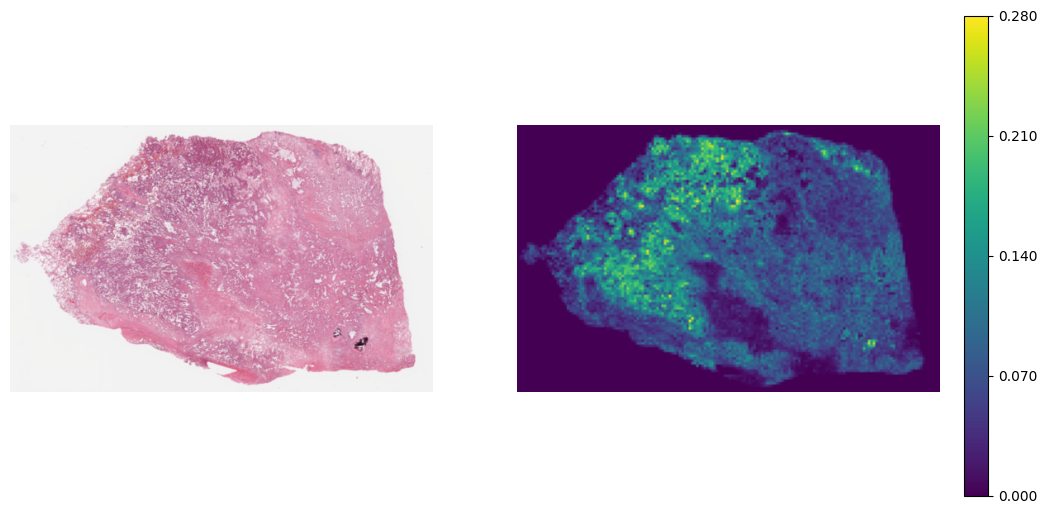

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

slide = get_image_slide(ref_series_uid)
thumbnail = slide.read_thumbnail()
axes[0].imshow(thumbnail)
axes[0].axis('off')

heatmap = create_heatmap(cellularity_per_tile)
min_max_scaled = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
hm = axes[1].imshow(min_max_scaled)
cax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
cbar = plt.colorbar(hm, cax=cax)
cbar.set_ticks(np.linspace(0, 1, num=5))
cbar.set_ticklabels([f'{x:.3f}' for x in np.linspace(heatmap.min(), heatmap.max(), num=5)])
axes[1].axis('off')

plt.show()

To finally have a quick-and-easy verifying look on regions of interest - in our case the tiles with the highest cellularity values - we access those tiles and overlay nuclei contours.

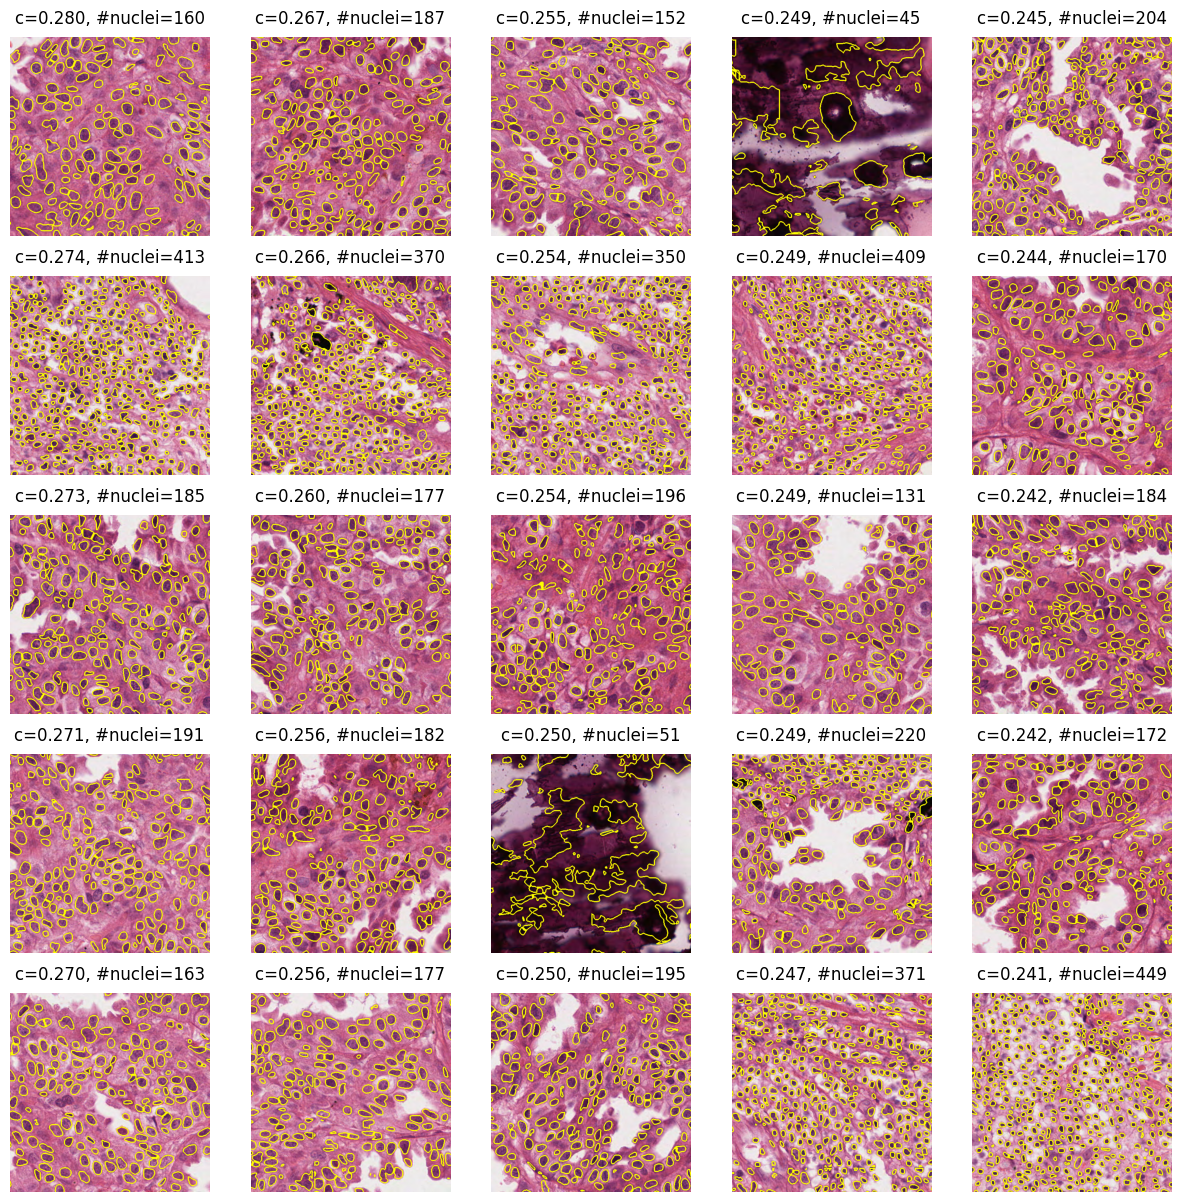

In [21]:
sorted_by_cellularity = cellularity_per_tile.sort_values('cellularity', ascending=False)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for i, (_, row) in enumerate(sorted_by_cellularity[:25].iterrows()):
    tile = slide.read_region(row.tile_coordinates, size=(TILE_SIZE, TILE_SIZE), level=0)
    overlay = overlay_polygons(tile, row.tile_coordinates, row.overlapping_polygons)
    axes[i%5, i//5].imshow(overlay)
    axes[i%5, i//5].set_title(f'c={row.cellularity:.3f}, #nuclei={row.number_nuclei}', fontsize=12, pad=10)

for ax in axes.flat:
    ax.set_axis_off()
plt.show()

We can see that most tiles indeed contain a large number of nuclei. Two tiles, however, clearly differ and likely show artifacts where the algorithm predicted nuclei that are too small, too large or misshaped. In that case, the number of nuclei in a tile might be a better indicator of cellularity. Also cellularity as defined above will prefer less, but larger nuclei over more but smaller nuclei. Thus, below, we'll display the tiles with the largest number of nuclei.  

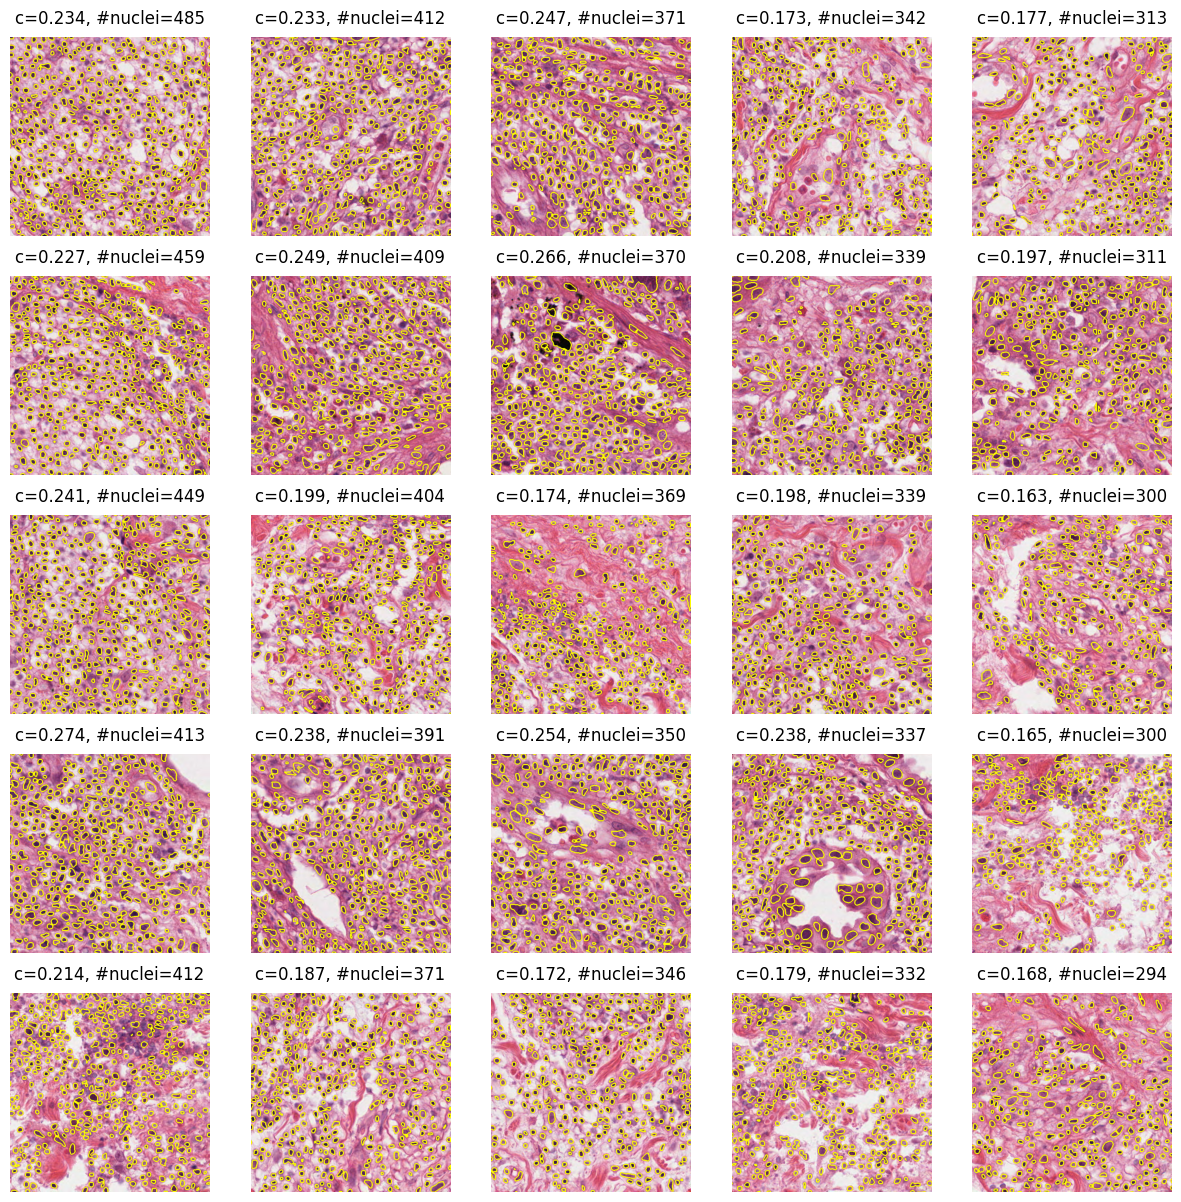

In [22]:
sorted_by_nuclei_number = cellularity_per_tile.sort_values('number_nuclei', ascending=False)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for i, (_, row) in enumerate(sorted_by_nuclei_number[:25].iterrows()):
    tile = slide.read_region(row.tile_coordinates, size=(TILE_SIZE, TILE_SIZE), level=0)
    overlay = overlay_polygons(tile, row.tile_coordinates, row.overlapping_polygons)
    axes[i%5, i//5].imshow(overlay)
    axes[i%5, i//5].set_title(f'c={row.cellularity:.3f}, #nuclei={row.number_nuclei}', fontsize=12, pad=10)

for ax in axes.flat:
    ax.set_axis_off()
plt.show()

## Exporting DICOM MBSAs to GeoJSON for usage in external tools

Since currently, some computational pathology tools use GeoJSON as their preferred file format for annotations, the following code shows how to easily export the nuclei contours captured in DICOM MBSAs as GeoJSON. Note, however, that the large amount of nuclei (sometimes about 1 billion per slide), may lead to quite large GeoJSON files. For demonstration purposes, we limit ourselves here to the first 50,000 nuclei.

In [23]:
def annotation_to_geojson_format(ann: np.ndarray) -> List[float]:
    ann = np.concatenate((ann, [ann[0]])) # add first coordinate to the end
    ann_3d = ann.reshape(1, *ann.shape) # return with extra dimension for GeoJSON compliance
    return ann_3d.tolist()

def ann_to_geojson(ann_path: str):
    geojson = {'type':'FeatureCollection', 'features':[]}

    ann_obj = hd.ann.annread(ann_path)
    nuclei_annotations = get_nuclei_annotations(ann_obj)
    nuclei_annotations_ = [annotation_to_geojson_format(ann) for ann in nuclei_annotations[:50000]]

    feature = {'type':'Feature',
               'properties': {},
               'geometry':{'type': None,
                           'coordinates':[]}}
    feature['properties'] = {'name': ann_obj.get_annotation_groups()[0].label}
    feature['geometry']['type'] = 'MultiPolygon'
    feature['geometry']['coordinates'] = nuclei_annotations_
    geojson['features'].append(feature)

    return geojson

In [24]:
geojson = ann_to_geojson(ann_path_example1)
with open('example.geojson', 'w') as output_file:
    json.dump(geojson, output_file, indent=2)

The resulting GeoJSON file can then be imported into other tools for viewing and analysis, such as for example [QuPath](https://qupath.github.io/). Here QuPath v.0.5.1 was used. After opening the slide, you can load the nuclei contours as GeoJSON via `File` > `Import objects from file` and adapt the visualization (e.g. changing color) in the `Annotations` panel.

<img src="https://github.com/ImagingDataCommons/IDC-Tutorials/releases/download/0.22.0/pan_cancer_annotation_qupath_example.png" alt="Example visualization of annotations" width="1000"/>

# Next steps
Share your feedback or ask questions about this notebook in IDC Forum: https://discourse.canceridc.dev.

If you are interested in tissue type annotations or want to learn about DICOM Structured Reporting, you can take a look at [this notebook](https://github.com/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/collections_demos/rms_mutation_prediction/RMS-Mutation-Prediction-Expert-Annotations_exploration.ipynb) navigating expert-generated region annotations for rhabdomyosarcoma tumor slides.



## Support

If you have any questions about this notebook, please post your question on the [IDC User Forum](https://discourse.canceridc.dev) or [open an issue](https://github.com/ImagingDataCommons/IDC-Tutorials/issues/new) in the [IDC Tutorials repository](https://github.com/ImagingDataCommons/IDC-Tutorials).

## Acknowledgments

Imaging Data Commons has been funded in whole or in part with Federal funds from the National Cancer Institute, National Institutes of Health, under Task Order No. HHSN26110071 under Contract No. HHSN261201500003I.

If you use IDC in your research, please cite the following publication:

> Fedorov, A., Longabaugh, W. J. R., Pot, D., Clunie, D. A., Pieper, S. D., Gibbs, D. L., Bridge, C., Herrmann, M. D., Homeyer, A., Lewis, R., Aerts, H. J. W., Krishnaswamy, D., Thiriveedhi, V. K., Ciausu, C., Schacherer, D. P., Bontempi, D., Pihl, T., Wagner, U., Farahani, K., Kim, E. & Kikinis, R. _National Cancer Institute Imaging Data Commons: Toward Transparency, Reproducibility, and Scalability in Imaging Artificial Intelligence_. RadioGraphics (2023). [https://doi.org/10.1148/rg.230180](https://doi.org/10.1148/rg.230180)